In [ ]:
library(readxl)

crop_bd <- read_excel('crop_recommendation_unida_corregida.xlsx')
glimpse(crop_bd)

New names:
• `` -> `...1`
Rows: 1,700
Columns: 21
$ ...1                  <dbl> 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55…
$ id                    <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 5…
$ N                     <dbl> 90, 85, 60, 74, 78, 69, 69, 94, 89, 68, 91, 90, 78, 93, 94, 60, 85, 91, 77, 88, 89, 76, 67, 83, 98, 66, 97, 97, 60, 84, 73, 92, 85, 98, 88, 95, 99, 95, 60, 63, 62, 64, 83, 82, 85, 91, 76, 74, 79, 88, 60, 76, 93, …
$ P                     <dbl> 42, 58, 55, 35, 42, 37, 55, 53, 54, 58, 53, 46, 58, 56, 50, 48, 38, 35, 38, 35, 45, 40, 59, 41, 47, 53, 59, 50, 49, 51, 57, 35, 37, 53, 54, 55, 57, 39, 43, 44, 42, 45, 60, 40, 52, 35, 49, 

Dado que vamos a seleccionar solo las variables relacionadas con el suelo, y el cultivo para etiquetar las nubes de puntos. Lo primero es crear una nueva variable que se llame `corp_es` y que contenga los nombres de los cultivos en español

In [ ]:
library(dplyr)
library(forcats)

crop <- crop_bd |> 
  select(N, P, K, humidity, ph, crop) |> 
  mutate(
    crop = as_factor(crop),
    crop_es = fct_recode(
      crop,
      manzana = 'apple',
      arroz = 'rice',
      banano = 'banana',
      frijol_arbustivo = 'blackgram',
      garbanzo = 'chickpea',
      coco = 'coconut',
      cafe = 'coffee',
      algodon = 'cotton',
      uva = 'grapes',
      frijol_rojo = 'kidneybeans',
      maiz = 'maize',
      arveja = 'mothbeans',
      naranja = 'orange',
      gandul = 'pigeonpeas',
      sandia = 'watermelon'
    )
  )

crop |> slice_sample(n = 10)

# A tibble: 10 × 7
       N     P     K humidity    ph crop       crop_es         
   <dbl> <dbl> <dbl>    <dbl> <dbl> <fct>      <fct>           
 1    24    14    33     93.3  6.37 coconut    coco            
 2     9    76    25     50.1  5.71 pigeonpeas gandul          
 3     0    23    15     93.4  7.60 orange     naranja         
 4    45    58    49     90.3  6.83 papaya     papaya          
 5    50    74    17     63.4  6.54 blackgram  frijol_arbustivo
 6   100    48    17     83.0  7.83 cotton     algodon         
 7    17    64    18     58.3  6.08 pigeonpeas gandul          
 8    36    26    26     51.1  6.82 mango      mango           
 9    63    42    21     72.3  5.80 maize      maiz            
10     4    43    18     61.1  8.84 mothbeans  arveja          

In [52]:
crop <- crop |> select(N, P, K, humidity, ph, crop_es)
glimpse(crop)

Rows: 1,700
Columns: 6
$ N        <dbl> 90, 85, 60, 74, 78, 69, 69, 94, 89, 68, 91, 90, 78, 93, 94, 60, 85, 91, 77, 88, 89, 76, 67, 83, 98, 66, 97, 97, 60, 84, 73, 92, 85, 98, 88, 95, 99, 95, 60, 63, 62, 64, 83, 82, 85, 91, 76, 74, 79, 88, 60, 76, 93, 65, 95, 75, 7…
$ P        <dbl> 42, 58, 55, 35, 42, 37, 55, 53, 54, 58, 53, 46, 58, 56, 50, 48, 38, 35, 38, 35, 45, 40, 59, 41, 47, 53, 59, 50, 49, 51, 57, 35, 37, 53, 54, 55, 57, 39, 43, 44, 42, 45, 60, 40, 52, 35, 49, 39, 43, 55, 36, 60, 56, 60, 52, 38, 5…
$ K        <dbl> 43, 41, 44, 40, 42, 42, 38, 40, 38, 38, 40, 42, 44, 36, 37, 39, 41, 39, 36, 40, 36, 43, 41, 43, 37, 41, 43, 41, 44, 35, 41, 40, 39, 38, 44, 42, 35, 36, 44, 41, 36, 43, 36, 40, 45, 38, 42, 38, 39, 45, 43, 39, 42, 43, 36, 39, 3…
$ humidity <dbl> 82.003, 80.320, 82.321, 80.158, 81.605, 83.370, 82.639, 82.894, 83.535, 83.033, 81.418, 81.451, 80.887, 82.057, 80.664, 80.300, 82.788, 80.418, 80.192, 83.588, 80.475, 83.117, 80.974, 82.678, 81.333, 80.524, 84.044, 80.545, 8…
$

In [74]:
library(FactoMineR)
library(factoextra)

pca_fit <- crop |>
  PCA(quali.sup = 6, graph = FALSE)

# Gráfico de varianza explicada

El gráfico de valores propios revela un claro “codo” en el segundo componente, lo que sugiere que la mayor parte de la información del conjunto de datos se concentra en los dos primeros ejes; por ello elegimos retener dos componentes principales, los cuales explican aproximadamente el 65 % de la varianza total, un nivel suficiente para extraer conclusiones robustas en un contexto exploratorio, al tiempo que simplifica la visualización y reduce la complejidad interpretativa sin incurrir en un sobreajuste significativo.

Aviso:
In geom_bar(stat = "identity", fill = barfill, color = barcolor,  :
  Ignoring empty aesthetic: `width`.


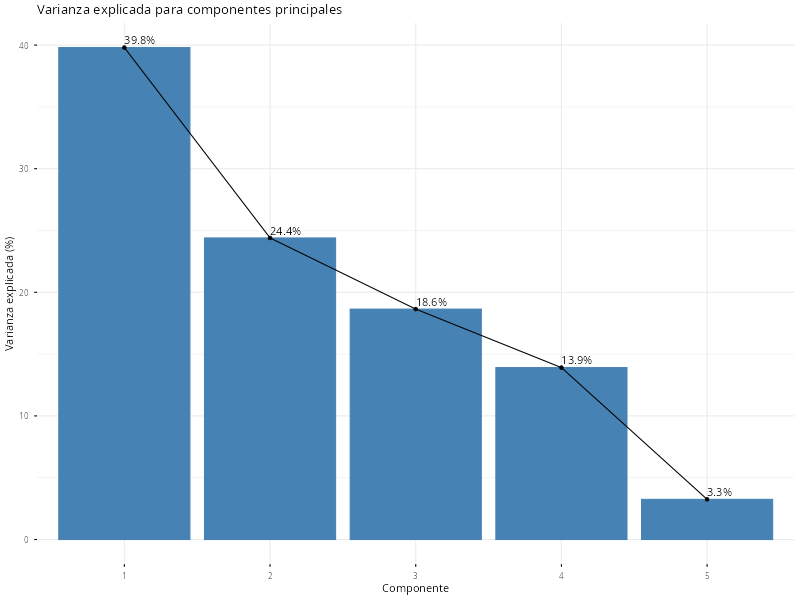

In [65]:
fviz_eig(pca_fit, addlabels = TRUE, 
  title = 'Varianza explicada para componentes principales', ylab = 'Varianza explicada (%)', xlab = 'Componente')

# Contribución de las variables

En términos generales, el primer componente agrupa las variables relacionadas con los nutrientes del suelo (potasio, fósforo y nitrógeno), lo que indica que la mayor parte de la variabilidad observada entre las muestras se explica por diferencias en la composición química. El segundo componente está dominado por la humedad ambiental, sugiriendo que la segunda dimensión captura variaciones debidas a las condiciones hidrológicas. Por consiguiente, el espacio de componentes puede interpretarse como un eje químico y otro eje hidrológico.

In [ ]:
facto_summarize(pca_fit, 'var', axes = 1)

             name      Dim.1      coord       cos2    contrib
N               N -0.4443556 0.19745193 0.19745193  9.9219467
P               P  0.9022092 0.81398136 0.81398136 40.9025104
K               K  0.9116022 0.83101857 0.83101857 41.7586292
humidity humidity  0.1255883 0.01577241 0.01577241  0.7925628
ph             ph -0.3630813 0.13182805 0.13182805  6.6243509

In [72]:
facto_summarize(pca_fit, 'var', axes = 2)

             name      Dim.2       coord        cos2     contrib
N               N 0.64271976 0.413088695 0.413088695 33.86154084
P               P 0.03392271 0.001150751 0.001150751  0.09432886
K               K 0.24439625 0.059729527 0.059729527  4.89612488
humidity humidity 0.83978779 0.705243534 0.705243534 57.80994021
ph             ph 0.20179746 0.040722217 0.040722217  3.33806521

In [73]:
facto_summarize(pca_fit, 'var')

             name      Dim.1      Dim.2     coord      cos2   contrib
N               N -0.4443556 0.64271976 0.6105406 0.6105406 19.020034
P               P  0.9022092 0.03392271 0.8151321 0.8151321 25.393626
K               K  0.9116022 0.24439625 0.8907481 0.8907481 27.749274
humidity humidity  0.1255883 0.83978779 0.7210159 0.7210159 22.461647
ph             ph -0.3630813 0.20179746 0.1725503 0.1725503  5.375419

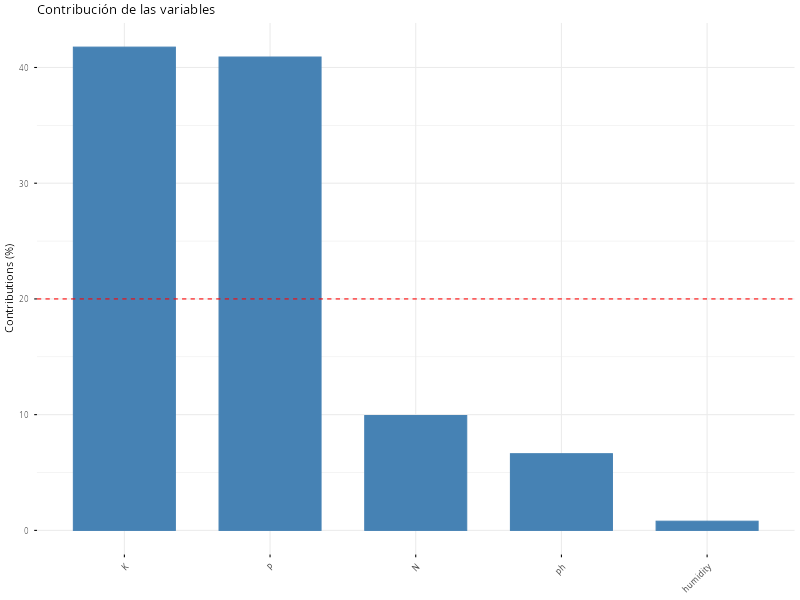

In [69]:
fviz_contrib(pca_fit, choice = 'var', axes = 1, title = 'Contribución de las variables')

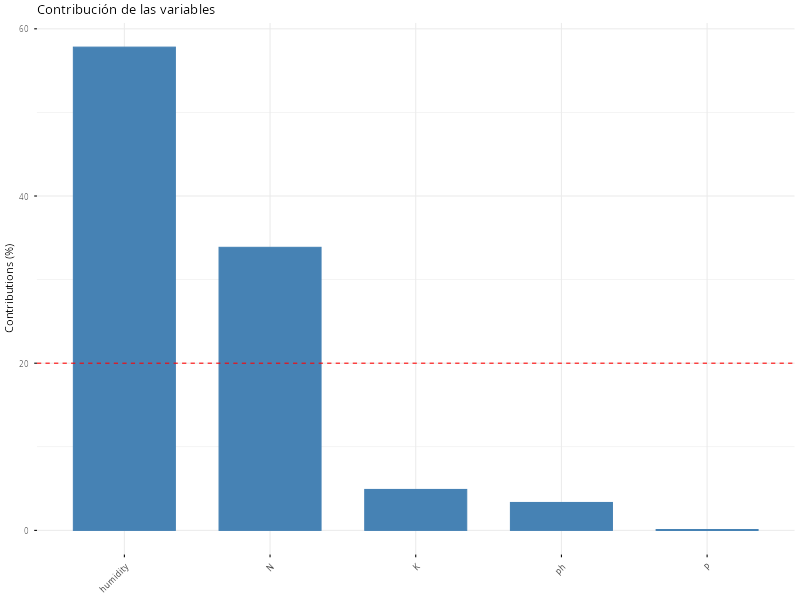

In [70]:
fviz_contrib(pca_fit, choice = 'var', axes = 2, title = 'Contribución de las variables')

# Biplot, nube de puntos y vectores de las variables

Dado que las variables seleccionadas están relacionadas con el suelo (NPK, pH, humedad), son estas características las que diferencian un cultivo de otro. En nuestro caso, se observan dos nubes bastante diferenciadas.

La primera y más evidente se encuentra a la derecha (manzana y uva). Esta se caracteriza por tener un nivel alto de fósforo y potasio, una humedad relativamente alta (en comparación con los demás puntos), un pH ácido y una baja concentración de nitrógeno.

La segunda nube puede dividirse en dos grupos, el primero está conformado por los cultivos banano y papaya y se sitúa sobre el vector humedad; en este aspecto, este suelo es ligeramente más húmedo que el mencionado anteriormente y presenta una mayor concentración de nitrógeno. Su pH tiende a ser neutro, y la concentración de fósforo y potasio es menor que en el primer grupo. El segundo grupo es más extenso y se localiza a la izquierda, mayormente entre el segundo y tercer cuadrante. Una característica común de esta nube es la baja concentración de fósforo y nitrógeno. No obstante, en las demás variables, la humedad puede variar desde suelos muy poco húmedos (frijol rojo, garbanzo, gandúl, mango y, en menor medida, frijol arbustivo) hasta suelos húmedos (algodón, sandía y arróz), aunque en menor medida que en el primer grupo. Por último, los cultivos de coco, maíz, naranja y café presentan un pH básico y una alta concentración de nitrógeno (especialmente en café y naranja).

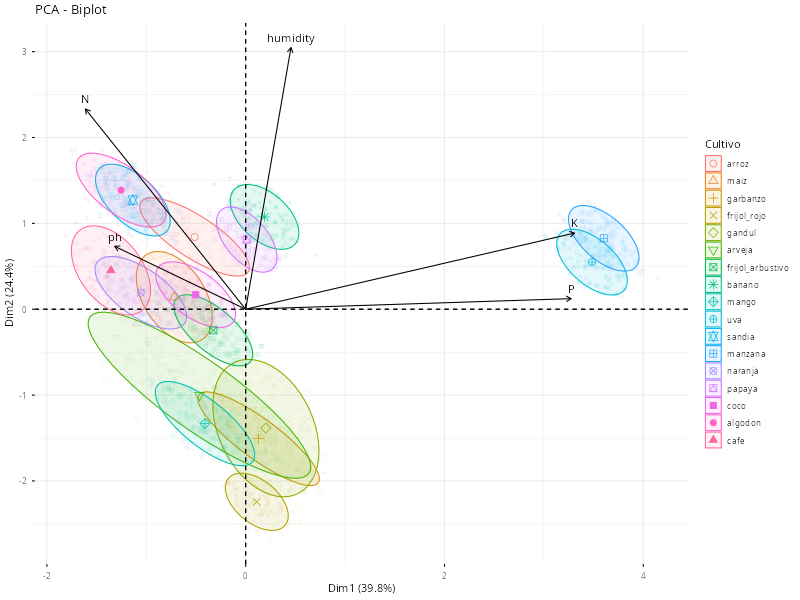

Ignoring unknown labels:
• linetype : "Cultivo"

In [58]:
fviz_pca_biplot(
  pca_fit,
  geom.ind = 'point',
  habillage = as.factor(crop$crop_es),
  alpha.ind = 0.1,
  col.var = 'black',
  legend.title = 'Cultivo',
  addEllipses = TRUE,
  ellipse.level=0.8
)